# K-Means Clustering

K-Means is an **unsupervised** algorithm: given *unlabeled* data, it groups the points into `k` clusters by similarity. You pick `k`; the algorithm finds the cluster centers on its own.

**Topics covered in this notebook**

1. Intuition
2. Clustering a dataset
3. Choosing k (the elbow method -  a visual technique used to find the optimal number of clusters (denoted as K))
4. When to use it

**1. Intuition**

K-Means repeats two steps until things stop moving:

1. **Assign** each point to the nearest cluster center (centroid).
2. **Update** each centroid to the mean of the points assigned to it.

It minimizes **inertia** — the total squared distance from points to their assigned centroid. Because it is distance-based, features should be on comparable scales, and results depend on the (random) starting centroids, so it is run several times and the best result kept (`n_init`).

**2. Clustering a Dataset**

We generate unlabeled 2-D data with three natural blobs and ask K-Means to recover three clusters. Note we never pass labels — the model only sees `X`.

In [3]:
# The make_blobs function is a built-in generator in Python's scikit-learn library 
# used to create synthetic datasets of isotropic Gaussian blobs for clustering and classification tasks
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [ ]:

# unlabeled data with 3 natural groups (the true groups are ignored - clustering is unsupervised)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

In [ ]:
# ask KMeans to find 3 clusters
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(X)

print("cluster label for first 10 points:", labels[:10])

cluster label for first 10 points: [1 1 0 2 1 2 0 2 0 0]
cluster centers:
 [[-2.61  9.04]
 [-6.88 -6.96]
 [ 4.73  2.  ]]
inertia (within-cluster sum of squares): 362.8


In [ ]:
print("cluster centers:\n", km.cluster_centers_.round(2))

In [ ]:
print("inertia (within-cluster sum of squares):", round(km.inertia_, 1))

**3. Choosing k (the Elbow Method)**

K-Means needs you to pick `k` up front. Inertia always drops as `k` grows (more clusters fit tighter), so you look for the **elbow** — the point where adding another cluster stops giving a big improvement. Here the sharp drop flattens after `k=3`, which matches the three blobs we created.

Inertia is a score that measures how tightly packed and cohesive the data points are inside their clusters. It calculates the sum of the squared distances from each data point to its assigned cluster center (centroid)

In [6]:
# try several k and watch inertia - the "elbow" hints at the right number of clusters
for k in range(1, 7):
    m = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    print(f"k={k} -> inertia {m.inertia_:9.1f}")

k=1 -> inertia   20120.5
k=2 -> inertia    5526.5
k=3 -> inertia     362.8
k=4 -> inertia     318.1
k=5 -> inertia     273.4
k=6 -> inertia     233.6


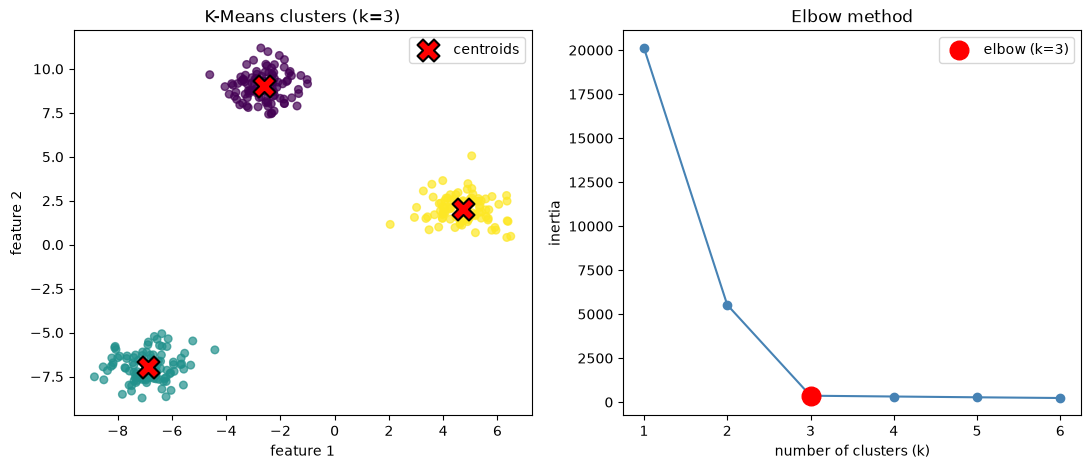

In [14]:
# Visualization
import matplotlib.pyplot as plt

# recompute the inertia curve so the plot is self-contained
ks = range(1, 7)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- left: clusters recovered by K-Means, colored by predicted label ---
scatter = ax1.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=30, alpha=0.7)
ax1.scatter(
    km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
    c="red", marker="X", s=250, edgecolor="black", linewidth=1.5, label="centroids",
)
ax1.set_title("K-Means clusters (k=3)")
ax1.set_xlabel("feature 1")
ax1.set_ylabel("feature 2")
ax1.legend()

# --- right: elbow curve — inertia vs. number of clusters ---
ax2.plot(ks, inertias, marker="o", color="steelblue")
ax2.scatter([3], [inertias[2]], color="red", s=180, zorder=5, label="elbow (k=3)")
ax2.set_title("Elbow method")
ax2.set_xlabel("number of clusters (k)")
ax2.set_ylabel("inertia")
ax2.legend()

plt.show()


**4. When to Use It**

- **Unsupervised** grouping when you have no labels (customer segments, document/topic grouping, image color quantization).
- Fast and scales well to large datasets.
- Requirements & caveats: you must **choose k**, features should be **scaled**, and it assumes roughly round, similarly-sized clusters — it struggles with elongated or uneven shapes (try DBSCAN or Gaussian mixtures there).
- Unlike the supervised algorithms in this folder, there is no "accuracy" — you judge quality with inertia, silhouette score, or domain sense.